In [8]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.11 — Prior-state dynamics: access vs maintenance (supporting analysis)

**How the cue enters the model — read this first.** Color (the prior cue) is **interleaved**
trial-to-trial, so it's tempting to think behavior should *switch states* as the cue flips. It
should not, and that is a property of this architecture: here **color is an input regressor to
each state's GLM** (input-driven observations) and **transitions are standard / input-blind**. A
latent state is therefore a *policy* ("weight the color regressor"), not a cue value. A
consistent prior-user **stays in** the high-color-weight state and lets the flipping color input
flip the bias *within* that state — it does not switch states with the cue. We verified the state
sequence is cue-blind (cue-conditioned prior-state posterior diff ≈ 0, p = 0.54), so the
interleaving does **not** contaminate dwell.

So **dwell here = slow, strategy-level persistence of the color-weighting policy**, and the
question this notebook asks is whether the prior-using state is **harder to enter** (access,
*entry* = inflow) or **harder to stay in** (maintenance, *dwell* = self-transition). Because
transitions are cue-blind, the transition matrix reflects only slow behavioral drift and is
weakly identified at ~620 trials/session — so treat this as a **supporting** analysis. The
**primary** prior-usage measure is occupancy × color-weight (the prior-index in 6.03, validated
against DDM drift in 6.10, r ≈ 0.22, p ≈ 0.03); dwell/entry here only dissociate *how* prior
usage is gained or lost, not whether it is present.

In [9]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.optimize import linear_sum_assignment

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

In [10]:
import json

processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"
# Track the model finalized in 6.00 (selected_model.json); fall back to XY__tgt if absent.
_sel = shared_dir / "selected_model.json"
SELECTED = json.loads(_sel.read_text())["config"] if _sel.exists() else "XY__tgt"
CONFIG = SELECTED

bundle = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
smodels = bundle["model"]["models"]
feats = bundle["config"]["model_features"]
K = bundle["best_k"]
data = bundle["data"]
ci = feats.index("color")
ref_w = -pooled.observations.params[:, 0, :]
prior_state = int(np.argmax(ref_w[:, ci]))
# state names as used in 6.02 (S-keyed); sname() falls back to S{k} if K differs.
state_names = {"S0": "Positive biased", "S1": "Negative biased", "S2": "Unbiased", "S3": "Lapse"}
sname = lambda k: state_names.get(f"S{k}", f"S{k}")
sess_md = session_metadata(pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")).set_index("session_id")
print(f"CONFIG={CONFIG}  K={K}  prior_state=S{prior_state} ({sname(prior_state)})")

CONFIG=XY__tgt  K=4  prior_state=S1 (Negative biased)


## 1. Per-session transition dynamics — **every** state (aligned to the shared basis)

For each state compute **dwell** = self-transition (maintenance) and **entry** = mean inflow
(access). Looking at all states is the control for the prior-state story: if dwell is
uniformly high (≈1) across every state, the "high prior-state dwell" is just a generally
sticky transition matrix, not a prior-specific maintenance signal.

In [11]:
def align_perm(w, ref):
    cost = np.array([[np.sum((w[i]-ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost); inv = np.empty_like(col); inv[col] = np.arange(len(col)); return inv

Ts = {}   # per-session aligned KxK transition matrix
rows = []
for sid, m in smodels.items():
    perm = align_perm(-m.observations.params[:, 0, :], ref_w)
    T = m.transitions.transition_matrix[np.ix_(perm, perm)]
    Ts[sid] = T
    df = data[sid]
    obs = df["choices"].values.astype(int).reshape(-1, 1); inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    post = m.expected_states(data=obs, input=inp, mask=msk)[0][:, perm]; v = msk[:, 0]
    rec = dict(session_id=sid, switch=(np.diff(np.argmax(post[v], 1)) != 0).mean())
    for k in range(K):                       # dwell/entry for every state, not just the prior state
        rec[f"dwell_S{k}"] = T[k, k]
        rec[f"dwell_time_S{k}"] = 1.0 / (1.0 - T[k, k] + 1e-9)
        rec[f"entry_S{k}"] = np.mean([T[j, k] for j in range(K) if j != k])
    rows.append(rec)
dyn = pd.DataFrame(rows).set_index("session_id").join(sess_md)
dwell_cols = [f"dwell_S{k}" for k in range(K)]
entry_cols = [f"entry_S{k}" for k in range(K)]

# group-mean dwell for every state (columns renamed to the 6.02 state names)
g_dwell = dyn.groupby(["subtype", "medication"], observed=True)[dwell_cols].mean()
g_dwell.columns = [sname(k) + (" *" if k == prior_state else "") for k in range(K)]
print(f"prior-state dynamics: {dyn.shape}   prior = {sname(prior_state)} (*)")
print("Mean DWELL (self-transition) of every state per group:")
g_dwell.round(3)

prior-state dynamics: (100, 17)   prior = Negative biased (*)
Mean DWELL (self-transition) of every state per group:


Positive biased  Negative biased *  Unbiased  Lapse
subtype      medication                                                     
HC           none                  0.925              0.873     0.989  0.607
bradykinetic off                   0.987              0.967     0.969  0.437
             on                    0.960              0.971     0.981  0.706
intermediate off                   0.981              0.984     0.997  0.002
             on                    0.917              0.962     0.985  0.000
tremor       off                   0.834              0.679     0.979  0.428
             on                    0.837              0.968     0.985  0.582

## 2. Within-subject OFF→ON for every state: access (entry) vs maintenance (dwell)

Paired OFF→ON Wilcoxon for **each** state's dwell and entry. If a medication effect is
specific to the prior state (and absent elsewhere) the maintenance story holds; if every
state moves together it's a global dynamics shift, not prior-specific.

In [12]:
pd_dyn = dyn[dyn["is_pd"] == 1].copy()
def paired(metric, sub):
    pv = (pd_dyn.pivot_table(index=["subject_id", "subtype"], columns="medication",
                             values=metric, observed=True).dropna(subset=["off", "on"]).reset_index())
    d = pv if sub is None else pv[pv["subtype"] == sub]
    k = int(metric.split("_S")[1]); fam = metric.split("_S")[0]
    base = dict(metric=fam, state=sname(k) + (" *" if k == prior_state else ""), group=sub or "all_PD")
    if len(d) < 3:
        return {**base, "n": len(d), "off": np.nan, "on": np.nan, "delta": np.nan, "p": np.nan}
    _, p = wilcoxon(d["off"], d["on"])
    return {**base, "n": len(d), "off": d["off"].mean(), "on": d["on"].mean(),
            "delta": (d["on"] - d["off"]).mean(), "p": p}

res = pd.DataFrame([paired(f"{fam}_S{k}", sub)
                    for fam in ["dwell", "entry"]
                    for k in range(K)
                    for sub in [None, "tremor", "bradykinetic"]])
print("Paired Wilcoxon OFF vs ON — dwell (maintenance) & entry (access) of EVERY state (* = prior):")
res.set_index(["metric", "state", "group"])[["n", "off", "on", "delta", "p"]].round(4)

Paired Wilcoxon OFF vs ON — dwell (maintenance) & entry (access) of EVERY state (* = prior):


n     off      on   delta       p
metric state             group                                           
dwell  Positive biased   all_PD        22  0.9105  0.8962 -0.0143  0.4826
                         tremor        11  0.8343  0.8365  0.0022  0.8311
                         bradykinetic  10  0.9872  0.9597 -0.0275  0.1055
       Negative biased * all_PD        22  0.8237  0.9693  0.1456  0.1870
                         tremor        11  0.6790  0.9683  0.2893  0.1475
                         bradykinetic  10  0.9669  0.9711  0.0042  0.4316
       Unbiased          all_PD        22  0.9755  0.9835  0.0080  0.3209
                         tremor        11  0.9794  0.9854  0.0059  0.3652
                         bradykinetic  10  0.9691  0.9812  0.0122  0.3223
       Lapse             all_PD        22  0.4125  0.6117  0.1992  0.1055
                         tremor        11  0.4280  0.5816  0.1536  0.3203
                         bradykinetic  10  0.4366  0.7059  0.2693  0.1934
entry  Positive biased   all_PD        22  0.0716  0.0233 -0.0483  0.4826
                         tremor        11  0.0403  0.0302 -0.0101  0.8311
                         bradykinetic  10  0.0797  0.0166 -0.0630  0.5566
       Negative biased * all_PD        22  0.0549  0.0785  0.0235  0.7745
                         tremor        11  0.0579  0.0903  0.0324  0.4648
                         bradykinetic  10  0.0564  0.0728  0.0164  1.0000
       Unbiased          all_PD        22  0.1628  0.0742 -0.0886  0.1055
                         tremor        11  0.2572  0.0870 -0.1702  0.0537
                         bradykinetic  10  0.0749  0.0314 -0.0434  0.6250
       Lapse             all_PD        22  0.0033  0.0039  0.0006  0.3705
                         tremor        11  0.0044  0.0019 -0.0024  0.2783
                         bradykinetic  10  0.0025  0.0065  0.0039  0.9219

## 3. Maintenance (dwell) OFF→ON for every state, per subtype, vs HC reference

One row per state (prior state marked *). If the OFF→ON change is confined to the prior-state
row in tremor, the maintenance-deficit claim is prior-specific; if rows move in parallel it is
a global stickiness shift.

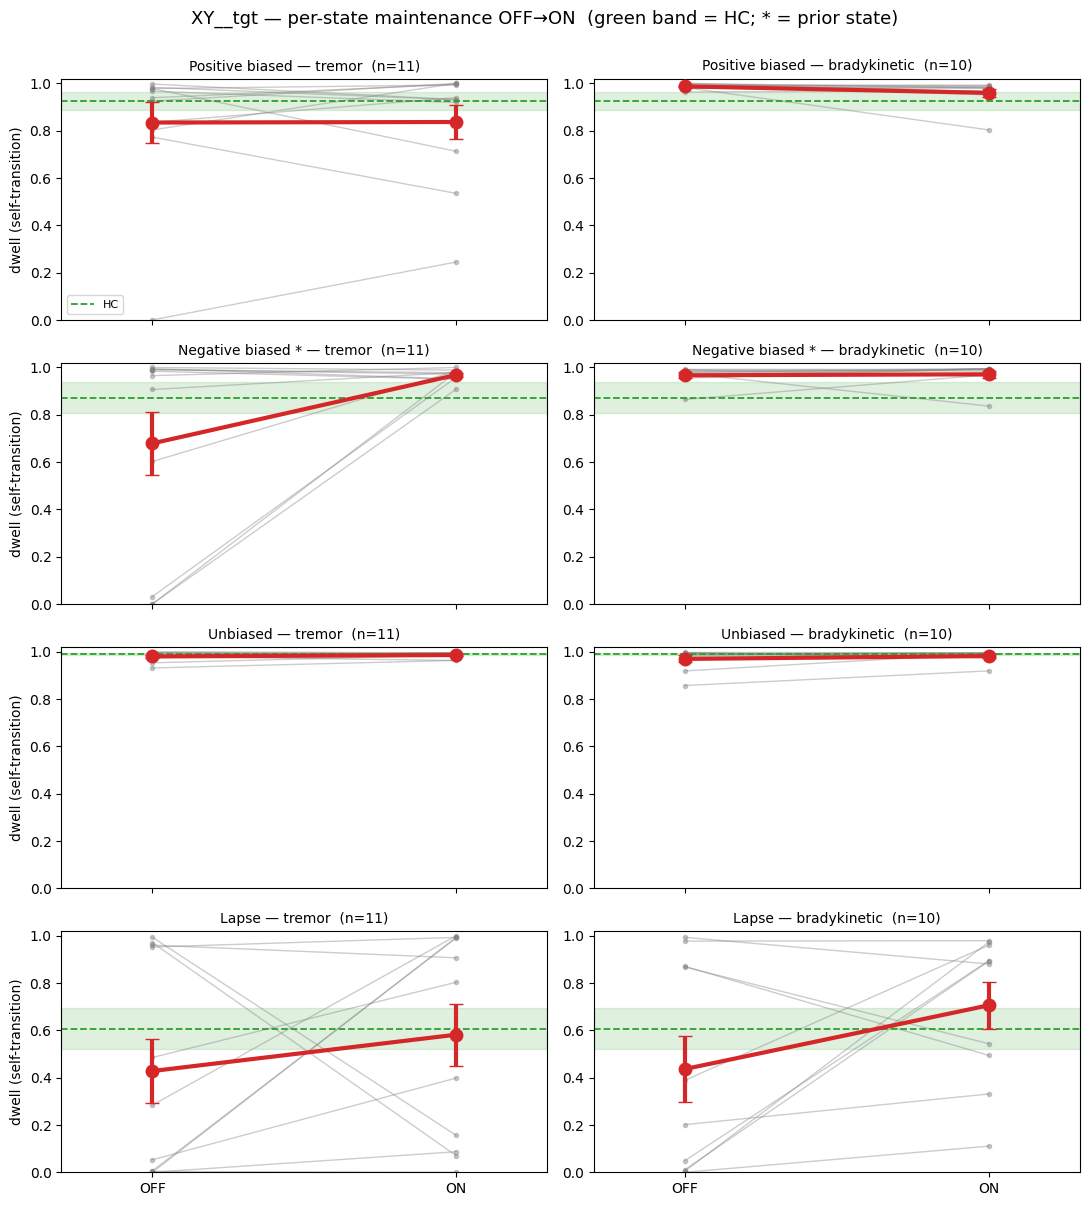

In [13]:
fig, axes = plt.subplots(K, 2, figsize=(11, 3.0 * K), sharex=True, squeeze=False)
for ki in range(K):
    metric = f"dwell_S{ki}"
    hc = dyn[dyn["subtype"] == "HC"][metric]; hc_m, hc_s = hc.mean(), hc.sem()
    for ax, sub in zip(axes[ki], ["tremor", "bradykinetic"]):
        pv = (pd_dyn.pivot_table(index="subject_id", columns="medication", values=metric, observed=True)
              .dropna(subset=["off", "on"]))
        sub_subj = pd_dyn[pd_dyn["subtype"] == sub]["subject_id"].unique()
        d = pv.loc[pv.index.isin(sub_subj)]
        for _, r in d.iterrows():
            ax.plot([0, 1], [r["off"], r["on"]], "-o", color="gray", alpha=0.4, lw=1, ms=3)
        ax.errorbar([0, 1], [d["off"].mean(), d["on"].mean()], yerr=[d["off"].sem(), d["on"].sem()],
                    color="tab:red", lw=3, marker="o", ms=9, capsize=5, zorder=5)
        ax.axhspan(hc_m - hc_s, hc_m + hc_s, color="tab:green", alpha=0.15)
        ax.axhline(hc_m, color="tab:green", ls="--", lw=1.3, label="HC")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.3); ax.set_ylim(0, 1.02)
        star = " *" if ki == prior_state else ""
        ax.set_title(f"{sname(ki)}{star} — {sub}  (n={len(d)})", fontsize=10)
    axes[ki, 0].set_ylabel("dwell (self-transition)")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{CONFIG} — per-state maintenance OFF→ON  (green band = HC; * = prior state)", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

## 4. Group-mean transition matrices

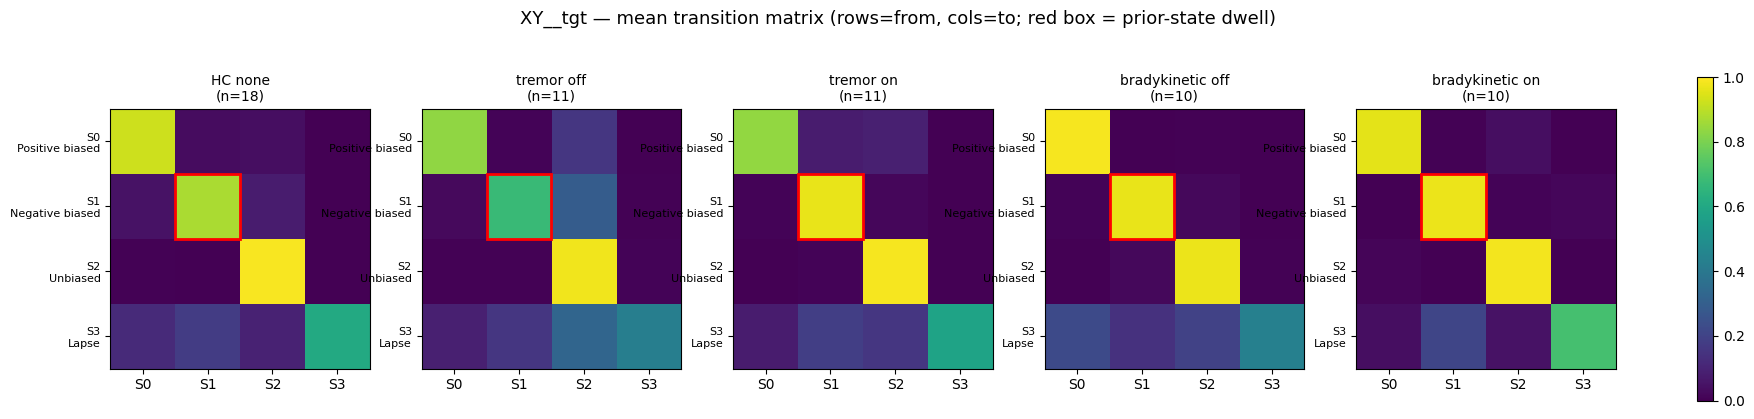

In [14]:
groups = [("HC","none"), ("tremor","off"), ("tremor","on"), ("bradykinetic","off"), ("bradykinetic","on")]
groups = [gp for gp in groups if ((dyn["subtype"]==gp[0]) & (dyn["medication"]==gp[1])).any()]
ticklab = [f"S{k}\n{sname(k)}" for k in range(K)]
fig, axes = plt.subplots(1, len(groups), figsize=(4.2*len(groups), 4.2), squeeze=False)
for ax, gp in zip(axes[0], groups):
    sids = dyn[(dyn["subtype"]==gp[0]) & (dyn["medication"]==gp[1])].index
    Tm = np.mean([Ts[s] for s in sids], axis=0)
    im = ax.imshow(Tm, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels([f"S{k}" for k in range(K)]); ax.set_yticklabels(ticklab, fontsize=8)
    ax.set_title(f"{gp[0]} {gp[1]}\n(n={len(sids)})", fontsize=10)
    # outline the prior state self-transition
    ax.add_patch(plt.Rectangle((prior_state-0.5, prior_state-0.5), 1, 1, fill=False, ec="red", lw=2))
fig.colorbar(im, ax=axes[0], fraction=0.025)
fig.suptitle(f"{CONFIG} — mean transition matrix (rows=from, cols=to; red box = prior-state dwell)", fontsize=13, y=1.04)
plt.show()

## 5. Read-out

**Interpretation.** Dwell here is the *persistence of the color-weighting policy* (the cue is
handled within-state, not by switching states), so the maintenance claim only holds if the
OFF→ON dwell change is **prior-state-specific**. In the all-states tables/grid above that is what
we see for tremor: prior-state (Negative biased) dwell rises OFF 0.68 → ON 0.97 (Δ≈+0.29) while
the other states do **not** show that jump and **entry** stays flat — consistent with a
maintenance, not access, effect. Brady is flat (prior dwell ≈0.97 both).

**Caveat this analysis was built to catch:** in brady the prior-state dwell is already near 1.0
*yet brady shows no prior bias* — so high dwell alone cannot produce prior usage. Dwell measures
how long a state persists *once entered*; it says nothing about whether that state is ever
occupied or how strongly it biases choice. **That** — occupancy × color-weight — is the
**primary** prior-usage measure (6.03 prior-index; 6.10 cross-model validation vs DDM drift,
r ≈ 0.22, p ≈ 0.03, the clean powered result). This notebook is **supporting**: it dissociates
access vs maintenance for *how* prior usage changes, with the honest limits that transitions are
cue-blind / weakly identified at ~620 trials and the tremor effect is directional but
underpowered (n = 11, p ≈ 0.15).